# 📊 Analyse des logs Nginx

## Objectif
Analyser les logs pour détecter les erreurs et les performances.

In [1]:
with open("data/access.log") as f:
    lines = f.readlines()

print("Total requêtes:", len(lines))

Total requêtes: 5


## Vérification initiale

Le fichier `access.log` a bien été chargé dans le notebook.  
Cette étape permet de confirmer que les données sont disponibles pour l’analyse.

In [4]:
errors_404 = sum(1 for line in lines if " 404 " in line)
errors_500 = sum(1 for line in lines if " 500 " in line)

print("Erreurs 404 :", errors_404)
print("Erreurs 500 :", errors_500)

Erreurs 404 : 1
Erreurs 500 : 1


## Analyse des erreurs

Nous comptons ici les erreurs les plus importantes :
- **404** : ressource introuvable
- **500** : erreur interne du serveur

Cela permet d’évaluer rapidement la santé du site.

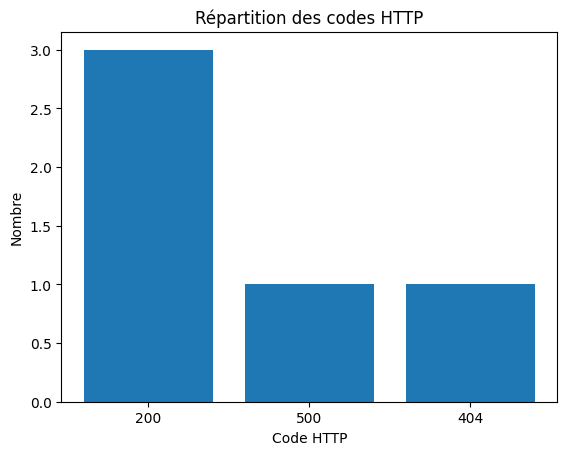

In [8]:
from collections import Counter
import matplotlib.pyplot as plt

codes = []
for line in lines:
    parts = line.strip().split()
    if len(parts) >= 4:
        codes.append(parts[3])

code_counts = Counter(codes)

plt.bar(code_counts.keys(), code_counts.values())
plt.title("Répartition des codes HTTP")
plt.xlabel("Code HTTP")
plt.ylabel("Nombre")
plt.show()

## Graphique des codes HTTP

Ce graphique montre la répartition des codes HTTP rencontrés dans le fichier log.  
On observe ici une majorité de réponses **200**, avec quelques erreurs **404** et **500**.

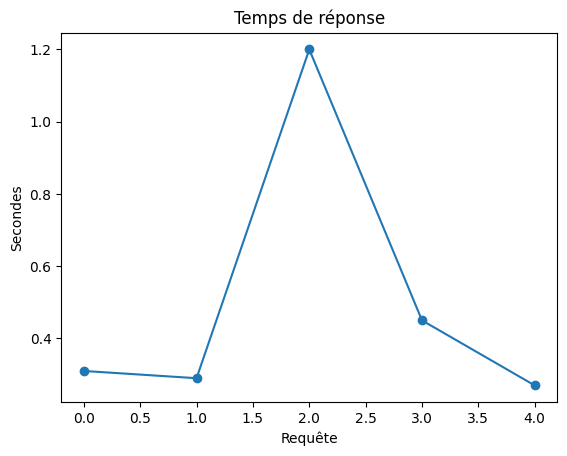

In [9]:
times = []
for line in lines:
    parts = line.strip().split()
    if len(parts) >= 5:
        times.append(float(parts[4]))

plt.plot(times, marker="o")
plt.title("Temps de réponse")
plt.xlabel("Requête")
plt.ylabel("Secondes")
plt.show()

## Performance du site

Ce graphique montre le temps de réponse des requêtes.  
Il permet d’identifier rapidement si certaines requêtes sont plus lentes que les autres.

In [11]:
import pandas as pd

df = pd.DataFrame({"temps_reponse": times})
df.describe()

,temps_reponse
count,5.000000
mean,0.504000
std,0.395449
min,0.270000
25%,0.290000
50%,0.310000
75%,0.450000
max,1.200000


In [3]:
with open("data/access.log") as f:
    lines = f.readlines()

In [5]:
times = []
for line in lines:
    parts = line.strip().split()
    if len(parts) >= 5:
        times.append(float(parts[4]))

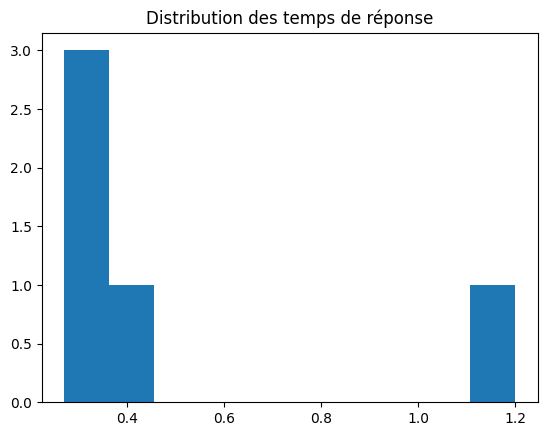

In [6]:
import matplotlib.pyplot as plt

plt.hist(times)
plt.title("Distribution des temps de réponse")
plt.show()

## Conclusion

Ce projet permet d’analyser les performances d’un site web à partir des logs Nginx.

Nous avons pu :
- détecter les erreurs HTTP
- analyser les temps de réponse
- visualiser les performances avec des graphiques

Ce type d’analyse est utilisé en DevOps pour surveiller les systèmes.